# Group 4 | Nancy Melchert, Sophia Menchaca, Blythe Weng

## Galaxy Classification

# INFORMATION ABOUT THE DATASET

From the [zenodo.org](https://zenodo.org/records/11117528) site:

## Overview

GalaxiesML is a machine learning-ready dataset of galaxy images, photometry, redshifts, and structural parameters. It is designed for machine learning applications in astrophysics, particularly for tasks such as redshift estimation and galaxy morphology classification. The dataset comprises **286,401 galaxy images** from the Hyper-Suprime-Cam (HSC) Survey PDR2 in five filters: g, r, i, z, y, with spectroscopically confirmed redshifts as ground truth.

This dataset is particularly useful for developing machine learning models for upcoming large-scale surveys like **LSST** and **Euclid**.

## Features

- **286,401 galaxy images** in five photometric bands (g, r, i, z, y).
- Spectroscopic redshifts for each galaxy, with redshift values ranging from **0.01 to 4**.
- Morphological parameters derived from galaxy images, including **Sérsic index**, **half-light radius**, and **ellipticity**.
- **Machine learning-friendly formats**: images are provided in **HDF5** format, along with CSV metadata.


## Examples of Using GalaxiesML

Examples of uses of GalaxiesML are outlined in Do et al. (2024). The repository for example code are here:

https://github.com/astrodatalab/galaxiesml_examples


## Citation

Please cite the following papers if you use this dataset in your work:

1. **GalaxiesML Dataset**:
- Do, T. et al., *GalaxiesML: A Dataset of Galaxy Images, Photometry, Redshifts, and Structural Parameters for Machine Learning*. arXiv:2410.00271 (2024), https://arxiv.org/abs/2410.00271 

2. **Hyper Suprime-Cam Subaru Strategic Program (HSC PDR2)**:
- Aihara, H., et al., *Second Data Release of the Hyper Suprime-Cam Subaru Strategic Program*. Publications of the Astronomical Society of Japan, 71(6), 114 (2019). DOI: [10.1093/pasj/psz103](https://doi.org/10.1093/pasj/psz103)

3. **Spectroscopic Surveys**:
- Several publicly available spectroscopic redshift catalogs were used in creating this dataset. Notable sources include:
- **zCOSMOS Survey**: Lilly, S. J., et al., *The zCOSMOS 10k-Bright Spectroscopic Sample*. The Astrophysical Journal Supplement Series, 184(2), 218-229 (2009). DOI: [10.1088/0067-0049/184/2/218](https://doi.org/10.1088/0067-0049/184/2/218)
- **VIMOS Public Extragalactic Survey (VIPERS)**: Garilli, B., et al., *The VIMOS Public Extragalactic Survey (VIPERS): First Data Release of 57,204 Spectroscopic Measurements*. Astronomy & Astrophysics, 562, A23 (2014). DOI: [10.1051/0004-6361/201322790](https://doi.org/10.1051/0004-6361/201322790)
- **DEEP2 Survey**: Newman, J. A., et al., *The DEEP2 Galaxy Redshift Survey: Design, Observations, Data Reduction, and Redshifts*. The Astrophysical Journal Supplement Series, 208(1), 5 (2013). DOI: [10.1088/0067-0049/208/1/5](https://doi.org/10.1088/0067-0049/208/1/5)


## How to Access

The dataset is publicly available on **Zenodo** with the DOI: **[10.5281/zenodo.11117528](https://doi.org/10.5281/zenodo.11117528)**.

## License

This dataset is licensed under a **Creative Commons Attribution 4.0 International License (CC BY 4.0)**. You are free to share and adapt the dataset as long as appropriate credit is given. For more details, visit: **[CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)**.

Please cite the references mentioned above if you use this dataset in your work.

THIS IS TO SEE IF I CAN FIGURE OUT THE PUSH/PULL AND GET IT INTO THE MAIN BRANCH

# DOWNLOAD AND EXPLORE THE DATASET

Datasets are `.hdf5`. The h5py package is a Pythonic interface to the HDF5 binary data format. 
[H5PY Documentation](https://docs.h5py.org/en/stable/)

In [ ]:
# install appropriate libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog

try:
    import torch
except ImportError:
    %pip install torch

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

try:
    import h5py
except ImportError: 
    %pip install h5py

In [ ]:
# Install Hugging Face datasets
%matplotlib inline
try:
    from datasets import load_dataset
except ImportError:
    %pip install datasets

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MLGalaxies Data

In [60]:
# CoPilot helped with this code snippet to create a custom PyTorch Dataset class for loading
class GalaxyDataset(Dataset):
    def __init__(self, hdf5_path, image_key="image", label_key=None):
        self.hdf5_path = hdf5_path
        self.image_key = image_key
        self.label_key = label_key

        # Open the file to get the length of the dataset, then close it
        with h5py.File(self.hdf5_path, "r") as f:
            self.length = f[self.image_key].shape[0]
    
        self.file = None  # Will hold the open HDF5 file

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        if self.file is None:
            # Open the file inside the active process
            self.file = h5py.File(self.hdf5_path, "r")

        #Extract data (HDF5 slicing loads only this slice into RAM)    
        image = self.file[self.image_key][idx]
        img_tensor = torch.tensor(image, dtype=torch.float32)

        if self.label_key is None:
            return img_tensor
        
        label = self.file[self.label_key][idx]
        label_tensor = torch.tensor(label, dtype=torch.long) if label is not None else None

        return img_tensor, label_tensor


In [ ]:
# Prompt user for the HDF5 file path for portability
# TODO: Update this to use a config file or environment variable for better reproducibility

Tk().withdraw()  # Hide the main window
Tk().attributes("-topmost", True)  # Bring the file dialog to the front

hdf5_path = filedialog.askopenfilename(
    title="Select HDF5 file for training", 
    filetypes=[("HDF5 files", "*.hdf5"), ("All files", "*.*")])

Tk().destroy()  # Close the file dialog

# Load the HDF5 file and read the images
if not hdf5_path:
    raise ValueError("No file selected. Please select an HDF5 file.")

with h5py.File(hdf5_path, "r") as f:
    print("Keys in the HDF5 file:", list(f.keys()))
# Use lazy-loading dataset
dataset = GalaxyDataset(hdf5_path, image_key="image", label_key=None)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f"Total Images: {len(dataset)}")

Keys in the HDF5 file: ['coord', 'dec', 'g_central_image_pop_10px_rad', 'g_central_image_pop_15px_rad', 'g_central_image_pop_5px_rad', 'g_cmodel_mag', 'g_cmodel_magsigma', 'g_ellipticity', 'g_half_light_radius', 'g_isophotal_area', 'g_major_axis', 'g_minor_axis', 'g_peak_surface_brightness', 'g_petro_rad', 'g_pos_angle', 'g_sersic_index', 'i_central_image_pop_10px_rad', 'i_central_image_pop_15px_rad', 'i_central_image_pop_5px_rad', 'i_cmodel_mag', 'i_cmodel_magsigma', 'i_ellipticity', 'i_half_light_radius', 'i_isophotal_area', 'i_major_axis', 'i_minor_axis', 'i_peak_surface_brightness', 'i_petro_rad', 'i_pos_angle', 'i_sersic_index', 'image', 'object_id', 'r_central_image_pop_10px_rad', 'r_central_image_pop_15px_rad', 'r_central_image_pop_5px_rad', 'r_cmodel_mag', 'r_cmodel_magsigma', 'r_ellipticity', 'r_half_light_radius', 'r_isophotal_area', 'r_major_axis', 'r_minor_axis', 'r_peak_surface_brightness', 'r_petro_rad', 'r_pos_angle', 'r_sersic_index', 'ra', 'skymap_id', 'specz_dec', 'sp

In [67]:
def print_image(idx=0, dataset=None, band_names=("g", "r", "i", "z", "y")):
    if dataset is None:
        raise ValueError("Pass your GalaxyDataset instance, e.g., print_image(0, dataset)")

    sample = dataset[idx]
    # GalaxyDataset returns (image_tensor); support image-only datasets too
    img_tensor = sample
    label_text = None

    flux = img_tensor.detach().cpu().numpy()  # expected shape: (C, H, W)

    plt.figure(figsize=(12, 3))
    for i in range(flux.shape[0]):
        plt.subplot(1, flux.shape[0], i + 1)
        title = band_names[i] if i < len(band_names) else f"band {i}"
        if i == 0 and label_text is not None:
            title = f"{title} | {label_text}"
        plt.title(title)
        plt.imshow(flux[i], cmap="gray_r", origin="lower")
        plt.axis("off")
    plt.tight_layout()  
    plt.show()

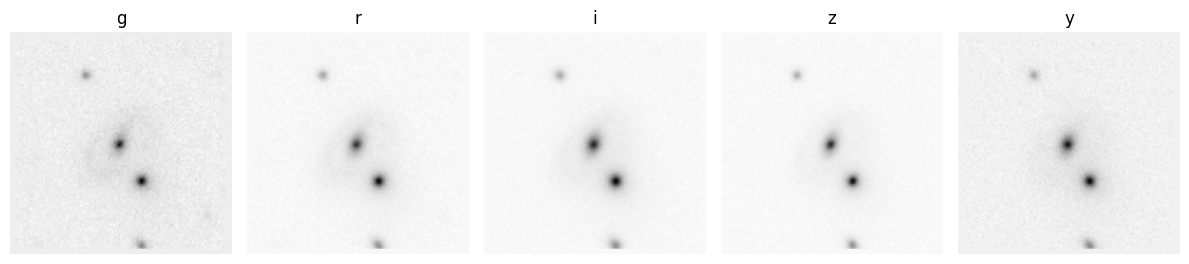

In [68]:
print_image(200, dataset)

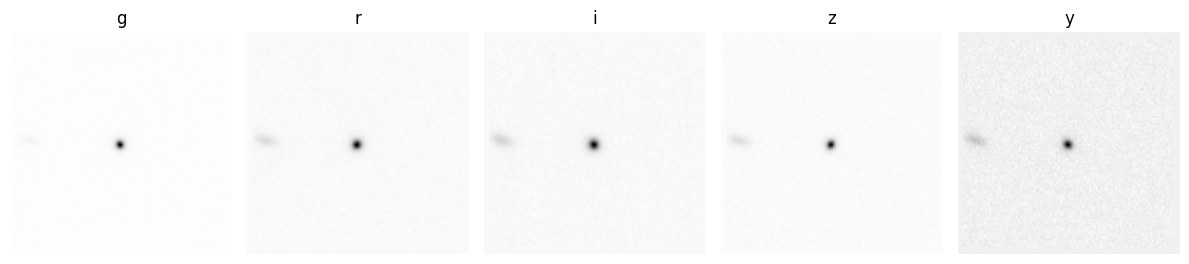

In [69]:
print_image(idx=0, dataset=dataset)

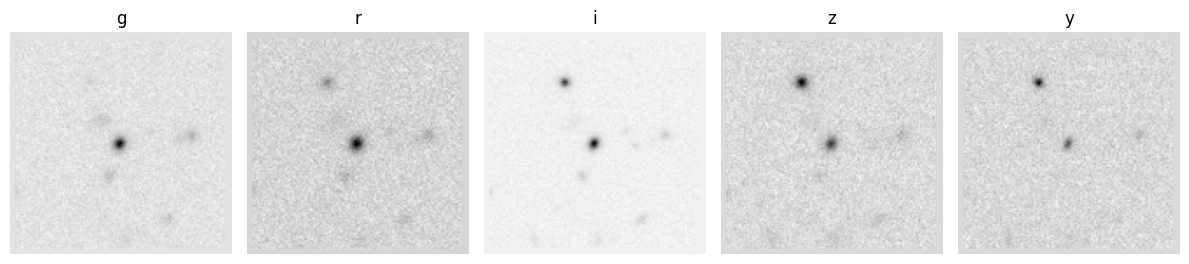

In [70]:
print_image(idx=9999, dataset=dataset)

In [ ]:
# csv files are inside a data folder, but then in .gitignore because of the size, so we need to specify the path to read them

images_df = pd.read_csv("5x127x127_training_with_morphology.csv")
print("CSV DataFrame shape:", images_df.shape)


CSV DataFrame shape: (204573, 84)


In [ ]:
images_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coord                         204573 non-null  object 
 1   dec                           204573 non-null  float64
 2   g_central_image_pop_10px_rad  204573 non-null  int64  
 3   g_central_image_pop_15px_rad  204573 non-null  int64  
 4   g_central_image_pop_5px_rad   204573 non-null  int64  
 5   g_cmodel_mag                  204573 non-null  float64
 6   g_cmodel_magsigma             204573 non-null  float64
 7   g_ellipticity                 204573 non-null  float64
 8   g_half_light_radius           204573 non-null  float64
 9   g_isophotal_area              204573 non-null  float64
 10  g_major_axis                  204573 non-null  float64
 11  g_minor_axis                  204573 non-null  float64
 12  g_peak_surface_brightness     204573 non-nul

In [ ]:
images_df.describe()

,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,g_major_axis,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
count,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,...,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000,204573.000000
mean,4.819285,1.015862,1.033543,0.998133,21.256327,0.009995,0.229963,6.508896,698.924804,5.528036,...,0.006686,0.231929,5.891219,803.493164,5.732100,4.060182,-6.812149,6.257465,1.829148,1.657161
std,14.836012,0.201299,0.242275,0.158129,1.888613,0.066851,0.171878,3.643963,912.827984,4.107583,...,0.033624,0.167484,3.168950,878.649336,3.687718,2.153258,1.429269,1.410914,52.351394,0.860905
min,-7.227071,0.000000,0.000000,0.000000,14.365486,0.000128,0.000000,-11.244000,0.000000,0.000000,...,0.000097,0.000000,0.000000,0.000000,0.000000,0.000000,-10.623000,0.000000,-90.000000,0.000000
25%,-0.963948,1.000000,1.000000,1.000000,19.719109,0.001517,0.094000,3.873000,121.000000,2.685000,...,0.000996,0.099000,3.678000,146.000000,2.827000,2.302000,-7.827900,5.280000,-43.810000,1.031000
50%,0.325055,1.000000,1.000000,1.000000,21.503017,0.004896,0.189000,5.667000,261.000000,3.917000,...,0.002083,0.195000,5.219000,491.000000,4.911000,3.726000,-6.994000,5.940000,3.600000,1.520000
75%,1.724730,1.000000,1.000000,1.000000,22.624615,0.011667,0.328000,7.991000,954.000000,7.273000,...,0.005968,0.326000,7.161000,1138.000000,7.514000,5.253000,-5.919700,6.600000,47.470000,2.093000
max,53.259826,3.000000,4.000000,3.000000,29.835554,28.564775,0.976000,42.020000,7530.000000,39.735000,...,12.755774,0.933000,40.717000,7534.000000,41.670000,16.890000,0.000000,10.560000,90.000000,9.915000


In [ ]:
images_df.head()

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


In [7]:
images_df.columns.tolist()

['coord',
 'dec',
 'g_central_image_pop_10px_rad',
 'g_central_image_pop_15px_rad',
 'g_central_image_pop_5px_rad',
 'g_cmodel_mag',
 'g_cmodel_magsigma',
 'g_ellipticity',
 'g_half_light_radius',
 'g_isophotal_area',
 'g_major_axis',
 'g_minor_axis',
 'g_peak_surface_brightness',
 'g_petro_rad',
 'g_pos_angle',
 'g_sersic_index',
 'i_central_image_pop_10px_rad',
 'i_central_image_pop_15px_rad',
 'i_central_image_pop_5px_rad',
 'i_cmodel_mag',
 'i_cmodel_magsigma',
 'i_ellipticity',
 'i_half_light_radius',
 'i_isophotal_area',
 'i_major_axis',
 'i_minor_axis',
 'i_peak_surface_brightness',
 'i_petro_rad',
 'i_pos_angle',
 'i_sersic_index',
 'object_id',
 'r_central_image_pop_10px_rad',
 'r_central_image_pop_15px_rad',
 'r_central_image_pop_5px_rad',
 'r_cmodel_mag',
 'r_cmodel_magsigma',
 'r_ellipticity',
 'r_half_light_radius',
 'r_isophotal_area',
 'r_major_axis',
 'r_minor_axis',
 'r_peak_surface_brightness',
 'r_petro_rad',
 'r_pos_angle',
 'r_sersic_index',
 'ra',
 'skymap_id',
 '

Heat map with a few features. Also seeing that I can push this successfully again -S

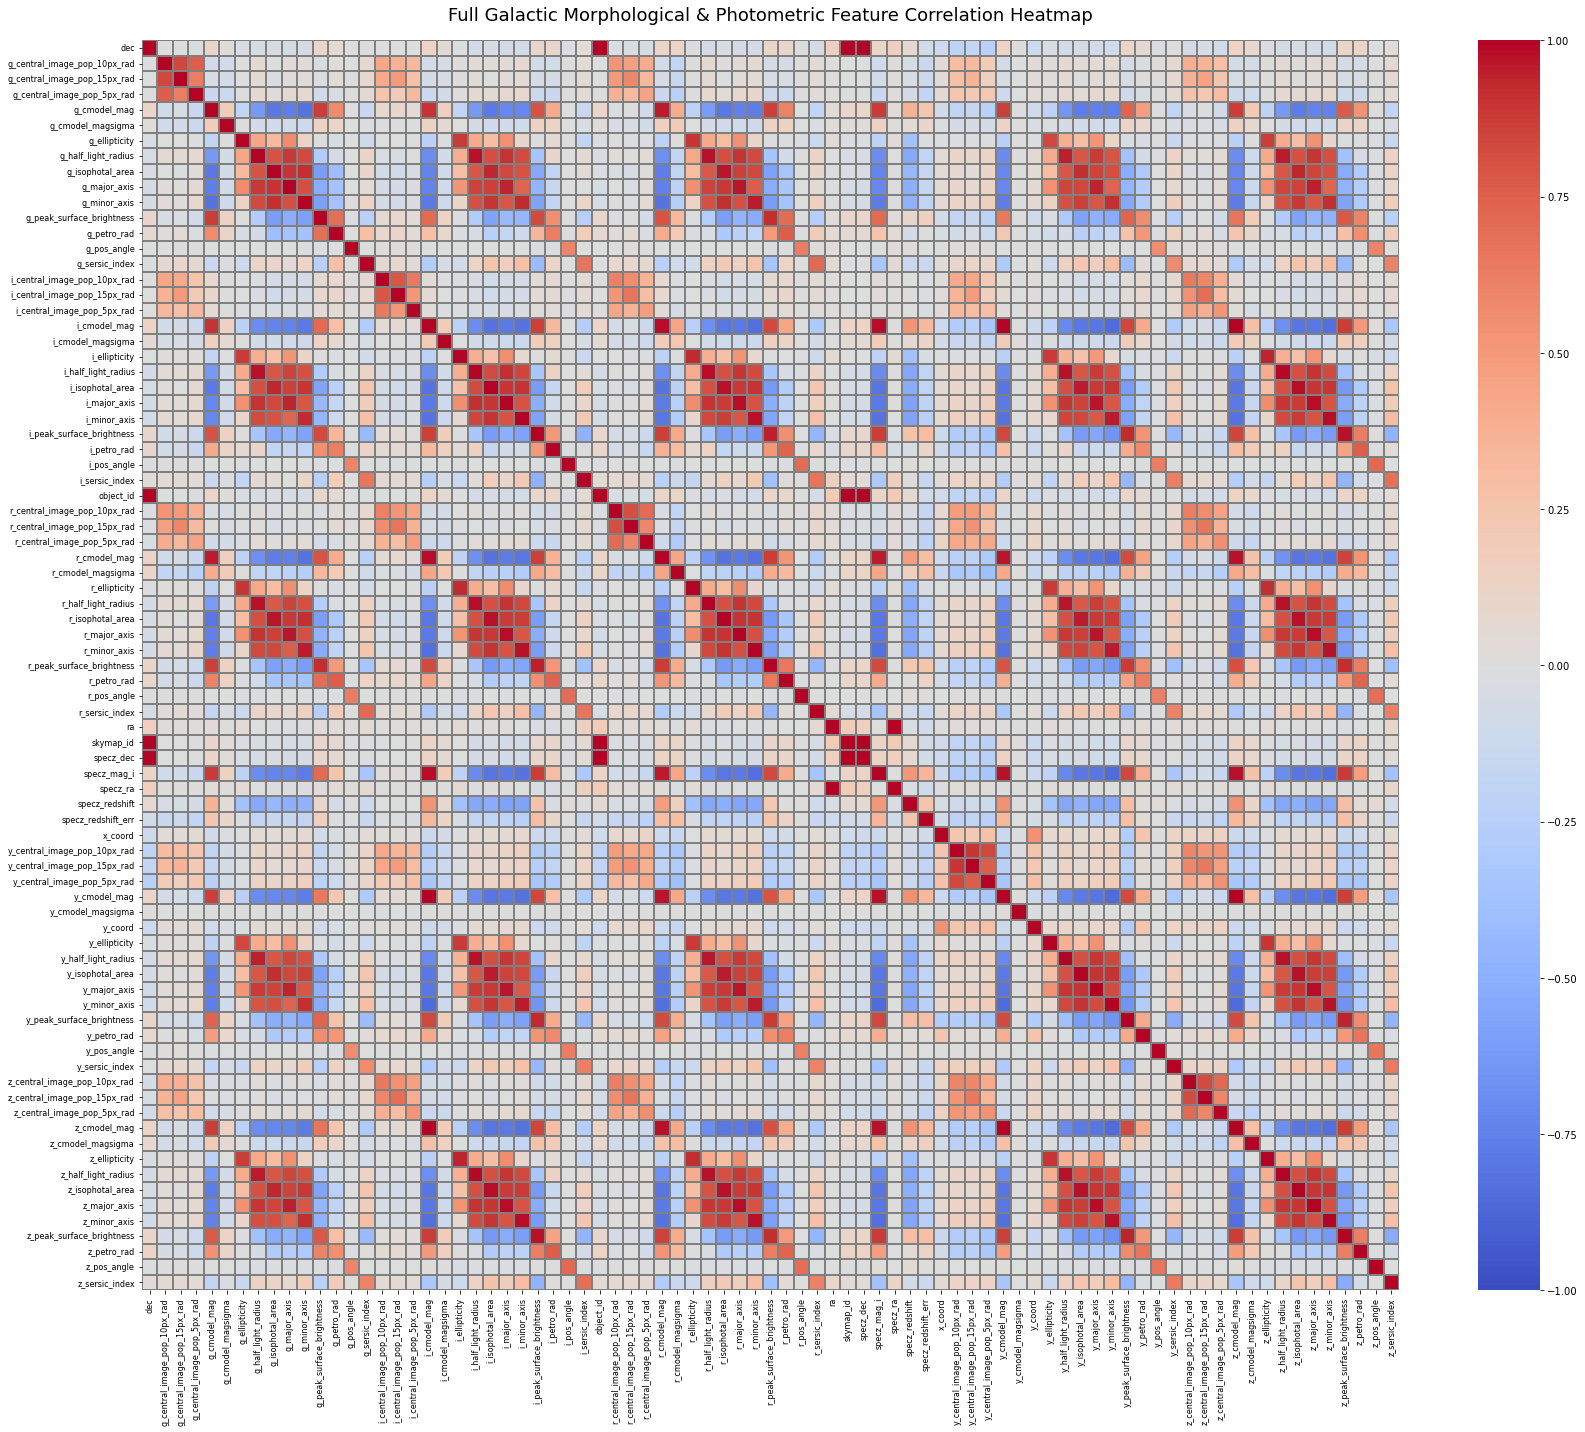

In [8]:

#Only keep features that have numbers
numeric_df = images_df.select_dtypes(include=['number'])
#Compute correlation matrix of all numeric features
full_corr_matrix = numeric_df.corr()
#create heatmap of the correlation matrix
plt.figure(figsize=(24, 20))
sns.heatmap(
    full_corr_matrix, 
    cmap="coolwarm",  
    vmin=-1, vmax=1,
    annot=False, 
    linewidths=0.05,
    linecolor='gray'
)

plt.title("Full Galactic Morphological & Photometric Feature Correlation Heatmap", fontsize=18, pad=20)
# vscode just filled in that title and it sounded cool
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Kind of insane looking, but very cool. Now just looking at a subset of the features, since there seems to be the same pattern accross different sets (g, i, r, y, z)



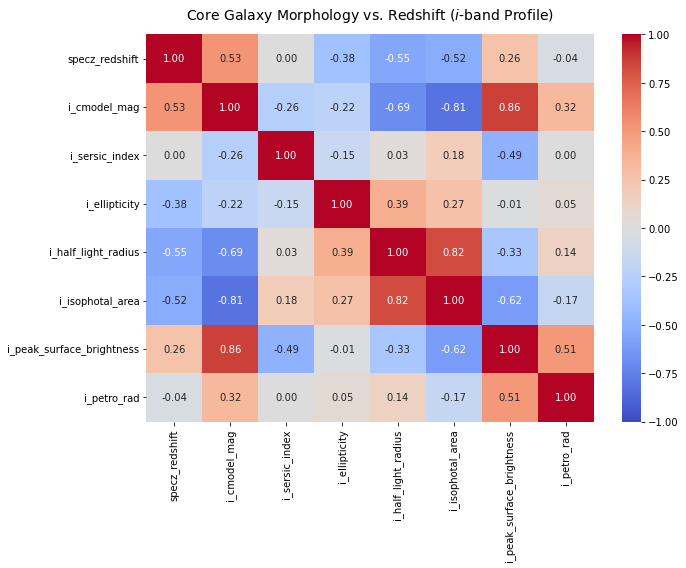

In [9]:
#I am pretty sure the i- band features are the most relevant to the redshift, so I will make a subset of those for a more focused correlation analysis. I will also include the spectroscopic redshift for this analysis, since that is the most accurate redshift measurement we have and is what we are trying to predict with our model.

morphology_subset = [
    'specz_redshift', 
    'i_cmodel_mag', 
    'i_sersic_index', 
    'i_ellipticity', 
    'i_half_light_radius', 
    'i_isophotal_area', 
    'i_peak_surface_brightness',
    'i_petro_rad'
]

plt.figure(figsize=(10, 8))
sns.heatmap(images_df[morphology_subset].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Core Galaxy Morphology vs. Redshift ($i$-band Profile)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [10]:
## Logistic Regression

Heat map with a few features. Also seeing that I can push this successfully again -S

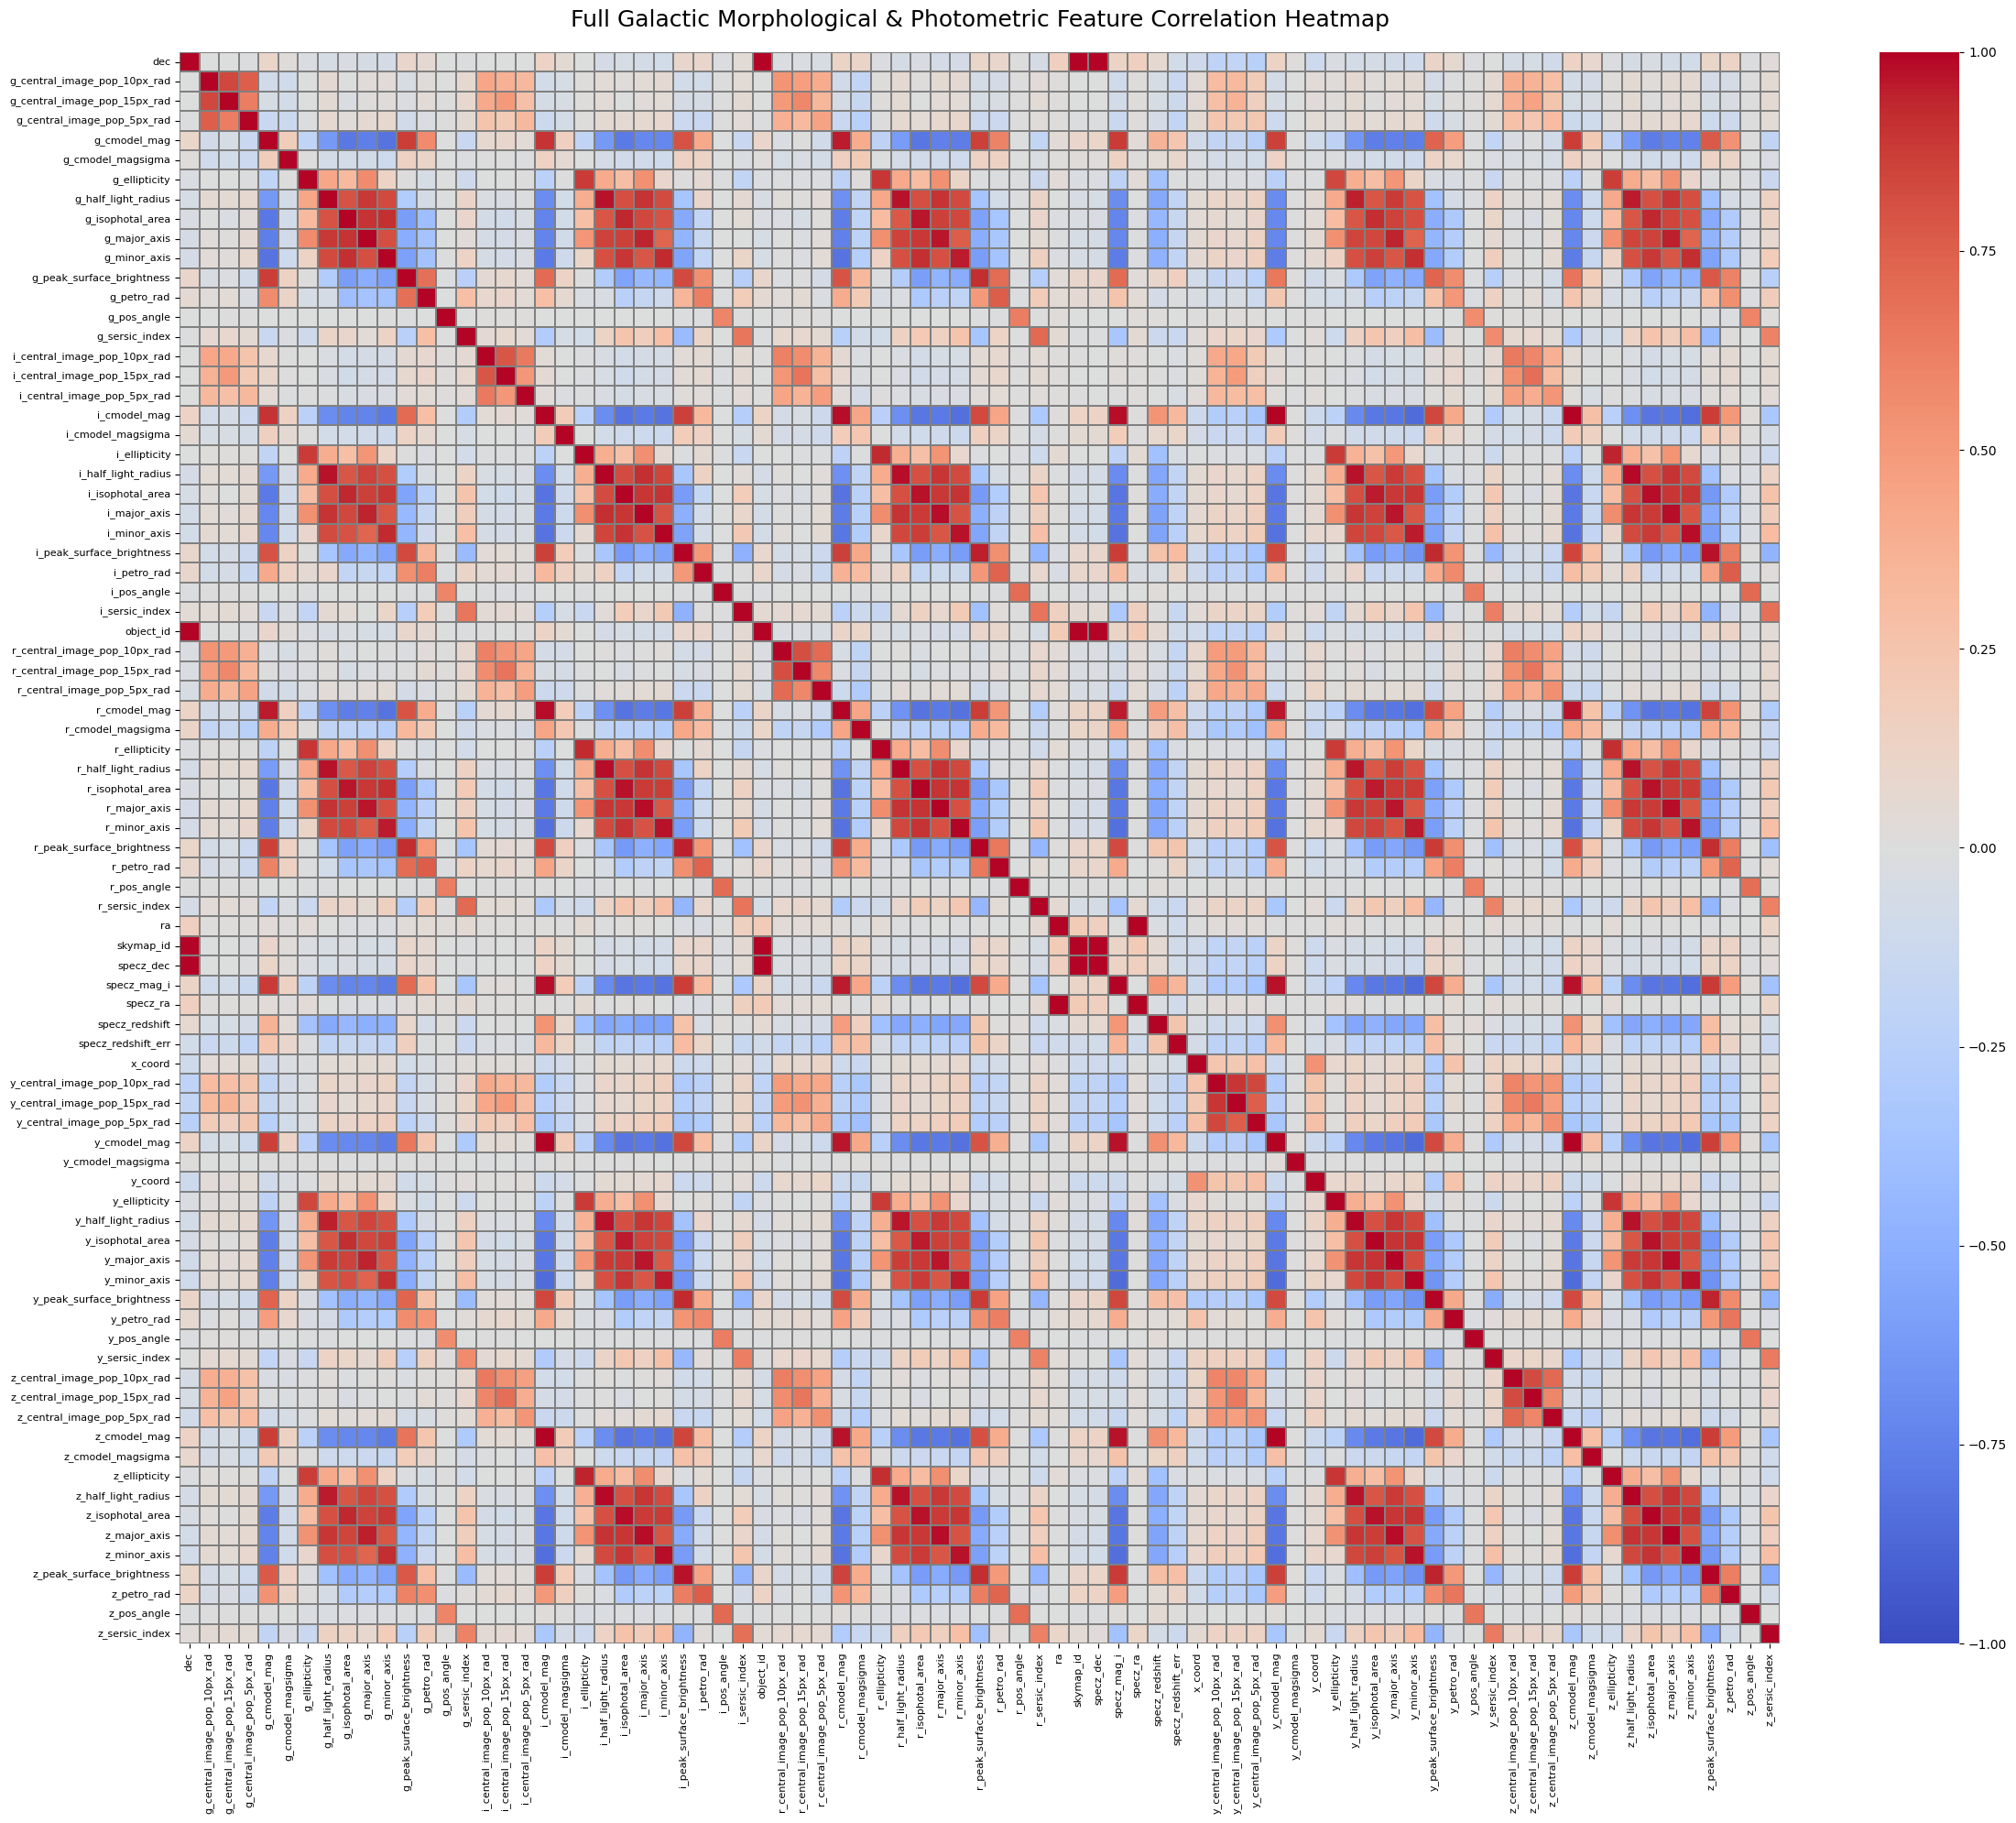

In [21]:

#Only keep features that have numbers
numeric_df = images_df.select_dtypes(include=['number'])
#Compute correlation matrix of all numeric features
full_corr_matrix = numeric_df.corr()
#create heatmap of the correlation matrix
plt.figure(figsize=(24, 20))
sns.heatmap(
    full_corr_matrix, 
    cmap="coolwarm",  
    vmin=-1, vmax=1,
    annot=False, 
    linewidths=0.05,
    linecolor='gray'
)

plt.title("Full Galactic Morphological & Photometric Feature Correlation Heatmap", fontsize=18, pad=20)
# vscode just filled in that title and it sounded cool
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Kind of insane looking, but very cool. Now just looking at a subset of the features, since there seems to be the same pattern accross different sets (g, i, r, y, z)



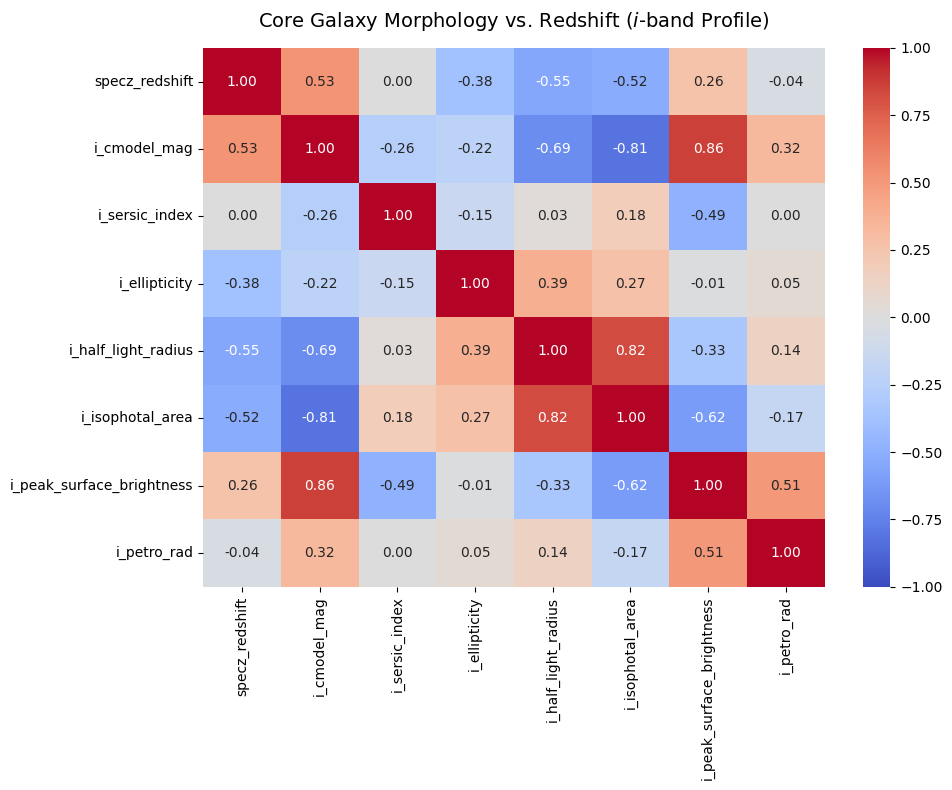

In [22]:
#I am pretty sure the i- band features are the most relevant to the redshift, so I will make a subset of those for a more focused correlation analysis. I will also include the spectroscopic redshift for this analysis, since that is the most accurate redshift measurement we have and is what we are trying to predict with our model.

morphology_subset = [
    'specz_redshift', 
    'i_cmodel_mag', 
    'i_sersic_index', 
    'i_ellipticity', 
    'i_half_light_radius', 
    'i_isophotal_area', 
    'i_peak_surface_brightness',
    'i_petro_rad'
]

plt.figure(figsize=(10, 8))
sns.heatmap(images_df[morphology_subset].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Core Galaxy Morphology vs. Redshift ($i$-band Profile)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Making some violin plots or boxplots to compare the different bands (g, r, i, z, y).)

C:\Users\smenc\AppData\Local\Temp\ipykernel_26272\2818831964.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


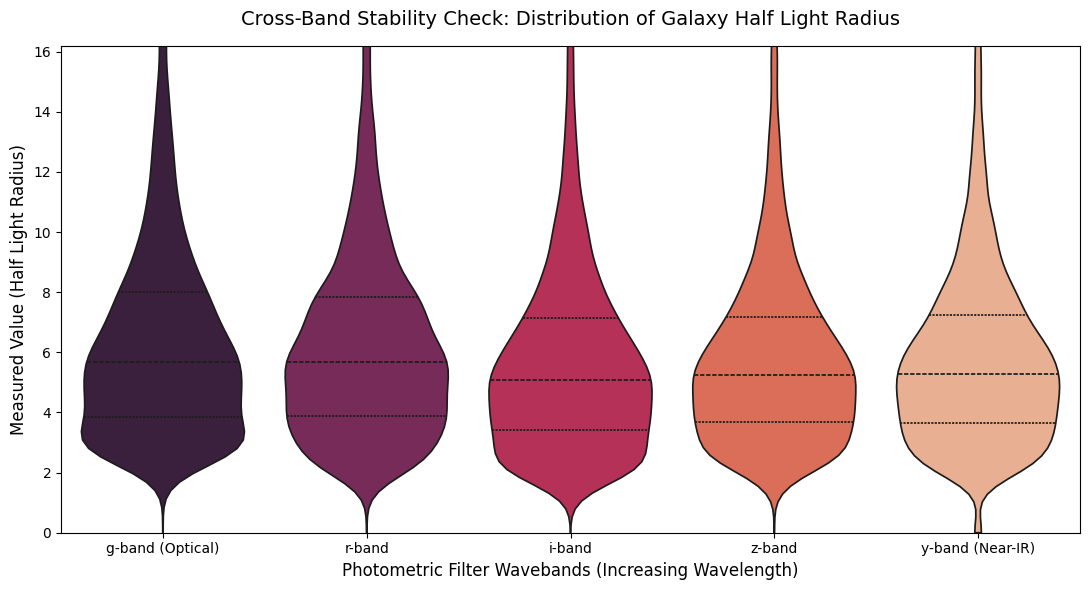

In [26]:
#'half_light_radius', 'sersic_index', 'ellipticity', 'cmodel_mag'
feature_to_plot = 'half_light_radius'

band_mapping = {
    f'g_{feature_to_plot}': 'g-band (Optical)',
    f'r_{feature_to_plot}': 'r-band',
    f'i_{feature_to_plot}': 'i-band',
    f'z_{feature_to_plot}': 'z-band',
    f'y_{feature_to_plot}': 'y-band (Near-IR)'
}

#use the band mapping to filter the columns in the dataframe, and only keep those that are present in the dataframe
valid_columns = [col for col in band_mapping.keys() if col in images_df.columns]

sampled_df = images_df[valid_columns].sample(min(10000, len(images_df)))
    
# Melt the wide DataFrame into a long-form structure for Seaborn compatibility
long_df = pd.melt(sampled_df, value_vars=valid_columns, var_name='Filter Band', value_name='Value')
long_df['Filter Band'] = long_df['Filter Band'].map(band_mapping)
    
plt.figure(figsize=(11, 6))
    
# Violin plots show both the box-plot summary stats and the raw kernel density probability
# violin plots are great for showing the distribution of values across different categories, 
# and they can reveal differences in the shape of the distribution that might not be apparent in box plots alone. 
# The 'inner' parameter set to 'quartile' adds lines for the median and quartiles, while 'cut=0' ensures that the violin shape is limited to the range of observed data, 
# preventing it from extending into areas with no data.
sns.violinplot(
    data=long_df, 
    x='Filter Band', 
    y='Value', 
    palette='rocket', 
    inner='quartile', 
    cut=0   #limits the violin shape strictly to observed data min/max
)
    

y_max = long_df['Value'].quantile(0.98)
plt.ylim(0, y_max)
    
clean_title = feature_to_plot.replace('_', ' ').title()
plt.title(f"Cross-Band Stability Check: Distribution of Galaxy {clean_title}", fontsize=14, pad=15)
plt.xlabel("Photometric Filter Wavebands (Increasing Wavelength)", fontsize=12)
plt.ylabel(f"Measured Value ({clean_title})", fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\smenc\AppData\Local\Temp\ipykernel_26272\3712383666.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


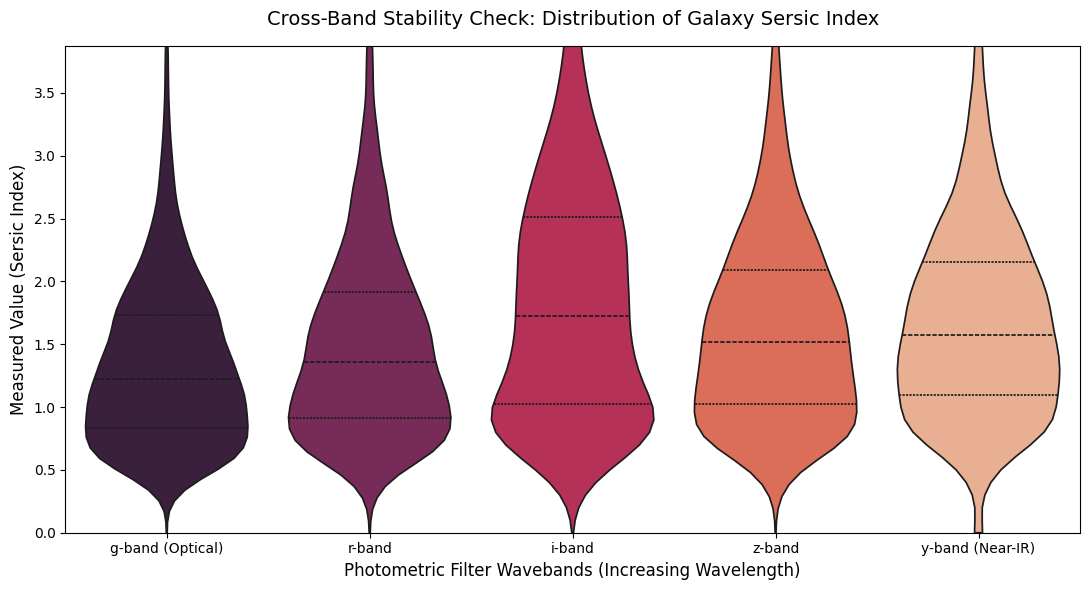

In [27]:
#'half_light_radius', 'sersic_index', 'ellipticity', 'cmodel_mag'
feature_to_plot = 'sersic_index'
# sersic index is a measure of the concentration of a galaxy's light profile, 
# and it can provide insights into the galaxy's morphology and structure. 
# By plotting the distribution of the sersic index across different photometric bands, 
# we can check for consistency in the measurements and identify any potential issues with the data 
# or the measurement process. If the distributions are similar across bands, 
# it suggests that the sersic index is being measured reliably regardless of the wavelength, 
# which is important for our model's ability to learn from these features effectively.

band_mapping = {
    f'g_{feature_to_plot}': 'g-band (Optical)',
    f'r_{feature_to_plot}': 'r-band',
    f'i_{feature_to_plot}': 'i-band',
    f'z_{feature_to_plot}': 'z-band',
    f'y_{feature_to_plot}': 'y-band (Near-IR)'
}

#use the band mapping to filter the columns in the dataframe, and only keep those that are present in the dataframe
valid_columns = [col for col in band_mapping.keys() if col in images_df.columns]

sampled_df = images_df[valid_columns].sample(min(10000, len(images_df)))
    
# Melt the wide DataFrame into a long-form structure for Seaborn compatibility
long_df = pd.melt(sampled_df, value_vars=valid_columns, var_name='Filter Band', value_name='Value')
long_df['Filter Band'] = long_df['Filter Band'].map(band_mapping)
    
plt.figure(figsize=(11, 6))

sns.violinplot(
    data=long_df, 
    x='Filter Band', 
    y='Value', 
    palette='rocket', 
    inner='quartile', 
    cut=0   #limits the violin shape strictly to observed data min/max
)
    

y_max = long_df['Value'].quantile(0.98)
plt.ylim(0, y_max)
    
clean_title = feature_to_plot.replace('_', ' ').title()
plt.title(f"Cross-Band Stability Check: Distribution of Galaxy {clean_title}", fontsize=14, pad=15)
plt.xlabel("Photometric Filter Wavebands (Increasing Wavelength)", fontsize=12)
plt.ylabel(f"Measured Value ({clean_title})", fontsize=12)
plt.tight_layout()
plt.show()

## JWST Dataset

In [11]:
# Image Samples
# This code is from the MultimodalUniverse Github repository, which is the source of our dataset. 
# It loads the dataset using Hugging Face's `datasets` library and retrieves an example to inspect its structure.
# Collab notebook: https://colab.research.google.com/github/MultimodalUniverse/MultimodalUniverse/blob/main/notebooks/getting_started.ipynb

dset_ls = load_dataset("MultimodalUniverse/jwst", 
                       streaming=True, 
                       split="train")
dset_ls = dset_ls.with_format("numpy")
dset_iterator = iter(dset_ls)

In [ ]:
example = next(dset_iterator)

In [ ]:
example.keys()

dict_keys(['image', 'mag_auto', 'flux_radius', 'flux_auto', 'fluxerr_auto', 'cxx_image', 'cyy_image', 'cxy_image', 'object_id'])

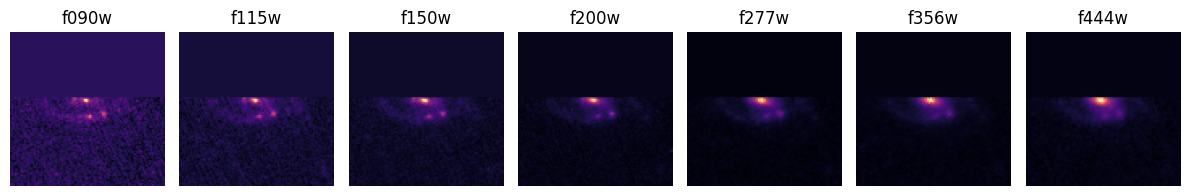

In [ ]:
plt.figure(figsize=(12, 5))
n_bands = len(example["image"]["band"])
for i, b in enumerate(example["image"]["band"]):
    plt.subplot(1, n_bands, i + 1)
    plt.title(f"{b}")
    plt.imshow(example["image"]["flux"][i], cmap="magma")
    plt.axis("off")
plt.tight_layout()


Info about the photometric filters used in the JWST dataset: https://jwst-docs.stsci.edu/jwst-mid-infrared-instrument/miri-instrumentation/miri-filters-and-dispersers#gsc.tab=0

### Adapting a CNN for 5 channels

Standard pre-trained CNNs expect 3 channels (RGB). GalaxyML data has 5 channels (u, g, r, i, z). We will modify a standard `ResNet18` to accept 5 channels

In [ ]:
def get_galaxy_model():
    # Start with an untrained ResNet-18 model
    model = models.resnet18(weights=None)  
    
    # Modify the first convolutional layer to accept 5 input channels instead of 3
    model.conv1 = nn.Conv2d(
        in_channels=5, 
        out_channels=64, 
        kernel_size=7, 
        stride=2, 
        padding=3, 
        bias=False
    )
    
    # Modify the final fully connected layer to output the number of classes (e.g., 10)
    num_classes = 3  # Update this based on your specific classification task
    model.fc = nn.Linear(
        in_features=model.fc.in_features, 
        out_features=num_classes
    )
    
    return model

Index(['gz10_label', 'redshift', 'object_id', 'rgb_pixel_scale'], dtype='object')


,gz10_label,redshift,object_id,rgb_pixel_scale
0,0,0.072587,904,0.262
1,1,0.134578,1558,0.262
2,1,0.129557,1768,0.262
3,2,0.127358,4520,0.262
4,4,0.041413,7653,0.262


In [19]:
# Refer to this link here
# https://github.com/henrysky/Galaxy10/blob/master/README.rst
# gz10 mappings to galaxy type
"""
Galaxy10 dataset (17736 images)
├── Class 0 (1081 images): Disturbed Galaxies
├── Class 1 (1853 images): Merging Galaxies
├── Class 2 (2645 images): Round Smooth Galaxies
├── Class 3 (2027 images): In-between Round Smooth Galaxies
├── Class 4 ( 334 images): Cigar Shaped Smooth Galaxies
├── Class 5 (2043 images): Barred Spiral Galaxies
├── Class 6 (1829 images): Unbarred Tight Spiral Galaxies
├── Class 7 (2628 images): Unbarred Loose Spiral Galaxies
├── Class 8 (1423 images): Edge-on Galaxies without Bulge
└── Class 9 (1873 images): Edge-on Galaxies with Bulge
"""

'\nGalaxy10 dataset (17736 images)\n├── Class 0 (1081 images): Disturbed Galaxies\n├── Class 1 (1853 images): Merging Galaxies\n├── Class 2 (2645 images): Round Smooth Galaxies\n├── Class 3 (2027 images): In-between Round Smooth Galaxies\n├── Class 4 ( 334 images): Cigar Shaped Smooth Galaxies\n├── Class 5 (2043 images): Barred Spiral Galaxies\n├── Class 6 (1829 images): Unbarred Tight Spiral Galaxies\n├── Class 7 (2628 images): Unbarred Loose Spiral Galaxies\n├── Class 8 (1423 images): Edge-on Galaxies without Bulge\n└── Class 9 (1873 images): Edge-on Galaxies with Bulge\n'

In [20]:
print(gz10.features)
print(gz10.info)

{'gz10_label': Value('int32'), 'redshift': Value('float32'), 'object_id': Value('string'), 'rgb_image': Image(mode=None, decode=True), 'rgb_pixel_scale': Value('float32')}
DatasetInfo(description='', citation='', homepage='', license='', features={'gz10_label': Value('int32'), 'redshift': Value('float32'), 'object_id': Value('string'), 'rgb_image': Image(mode=None, decode=True), 'rgb_pixel_scale': Value('float32')}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='gz10', config_name='default', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=2542804184, num_examples=17736, shard_lengths=[3600, 3400, 3568, 3500, 3668], original_shard_lengths=None, dataset_name='gz10')}, download_checksums={'hf://datasets/MultimodalUniverse/gz10@eed0f087b8e3eb3316d303a8244199c2667d46fb/gz10_rgb_images/train-00000-of-00002.parquet': {'num_bytes': 1293564173, 'checksum': None}, 'hf://datasets/MultimodalUniverse/gz10@eed0f087b8e3eb3316d303a8244199c2667d46fb/g

In [27]:
print(images_df['object_id'].head(20))
print(gz10_df['object_id'].head(20))

0     36407046198791272
1     36407046198803509
2     36407050493759629
3     36407050493760107
4     36407050493771757
5     36407050493773284
6     36407050493775097
7     36407050493775245
8     36407054788740340
9     36407054788741196
10    36407054788744371
11    36407059083690887
12    36407059083690946
13    36407059083707244
14    36407059083707750
15    36407059083710797
16    36407183637742656
17    36407187932710595
18    36407187932723873
19    36407192227679589
Name: object_id, dtype: int64
0       904
1      1558
2      1768
3      4520
4      7653
5     14778
6     14859
7     15508
8     16472
9     16998
10    10744
11     1522
12     7645
13     8466
14    12404
15    16955
16     8485
17      330
18     3359
19     3360
Name: object_id, dtype: object


In [37]:
df = images_df.copy()
df = df.dropna(subset=['i_sersic_index'])
# we need to determine a cutoff value to determine disk vs elliptical
# not sure what the exact cutoff should be
cutoff = 4
df['galaxy_type'] = (df['i_sersic_index'] >= cutoff).astype(int)

print(df['galaxy_type'].value_counts())
print(df['galaxy_type'])

0    196946
1      7627
Name: galaxy_type, dtype: int64
0         0
1         0
2         0
3         0
4         0
         ..
204568    0
204569    1
204570    0
204571    0
204572    0
Name: galaxy_type, Length: 204573, dtype: int64


In [39]:
# photometric filters
features = [
    'g_cmodel_mag',
    'r_cmodel_mag',
    'i_cmodel_mag',
    'z_cmodel_mag',
    'y_cmodel_mag'
]

model_df = df[feature_cols + ['galaxy_type']].dropna()

X = model_df[features]
y = model_df['galaxy_type']

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.48      0.65     39390
           1       0.05      0.63      0.08      1525

    accuracy                           0.49     40915
   macro avg       0.51      0.56      0.37     40915
weighted avg       0.94      0.49      0.62     40915



In [50]:
model = get_galaxy_model()
sample_input = torch.randn(2, 5, 127, 127)  # Batch size of 2, 5 channels, 127x127 image
output = model(sample_input)
print("Output shape:", output.shape)  # Should be (2, num_classes)

Output shape: torch.Size([2, 3])
